In [1]:
import os
from datasets import load_dataset

dataset_name = "SQuAD_2.0"

train_path = os.path.join(os.getcwd(), "Datasets", dataset_name, "train-00000-of-00001.parquet")
val_path = os.path.join(os.getcwd(), "Datasets", dataset_name, "validation-00000-of-00001.parquet")

dataset = load_dataset("parquet", data_files={'train': train_path, 'val': val_path})
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    val: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})

In [2]:
from datasets import DatasetDict

# time to reduce the dataset
reduced_train_set = dataset["train"].shuffle(seed=42).select(range(6500))
reduced_val_set = dataset["val"].shuffle(seed=42).select(range(650))
reduced_test_set = dataset["val"].shuffle(seed=42).select(range(650,1300))

reduced_set = DatasetDict({"train":reduced_train_set,
                           "val":reduced_val_set,
                           "test":reduced_test_set})

reduced_set

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 6500
    })
    val: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 650
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 650
    })
})

In [3]:
from processing import preprocess_train_function, preprocess_val_function, post_process

In [ ]:
small_eval_set = reduced_set["val"].shuffle().select(range(10))
eval_set = small_eval_set.map(
    preprocess_val_function,
    batched=True,
    remove_columns=small_eval_set.column_names,
)

eval_set

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'offset_mapping', 'start_positions', 'end_positions', 'example_id'],
    num_rows: 10
})

In [4]:
import torch
from transformers import AutoModelForQuestionAnswering

model_name = "distilbert/distilbert-base-uncased"

output_name = "test_bert"
final_checkpoint = os.path.join(os.getcwd(), "models", output_name, "checkpoint-750")

eval_set_for_model = eval_set.remove_columns(["example_id", "offset_mapping"])
eval_set_for_model.set_format("torch")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch = {k: eval_set_for_model[k].to(device) for k in eval_set_for_model.column_names}
trained_model = AutoModelForQuestionAnswering.from_pretrained(final_checkpoint).to(device)

with torch.no_grad():
    outputs = trained_model(**batch)

In [5]:
outputs

QuestionAnsweringModelOutput(loss=tensor(4.9468, device='cuda:0'), start_logits=tensor([[-1.8542, -1.8712, -2.5592,  ..., -6.2552, -6.2484, -6.2684],
        [-2.2604, -3.2329, -3.9079,  ..., -6.2330, -6.2568, -6.2949],
        [-2.2878, -4.4932, -3.9303,  ..., -6.3717, -6.4077, -6.4416],
        ...,
        [-2.4639, -4.2497, -4.9898,  ..., -5.3518, -5.9922, -4.6282],
        [-2.3289, -4.4381, -4.8752,  ..., -4.1431, -2.4472, -4.6670],
        [-2.4828, -3.8990, -4.7060,  ..., -6.3598, -6.3865, -6.4244]],
       device='cuda:0'), end_logits=tensor([[-2.8584, -3.5555, -3.6489,  ..., -6.6494, -6.6483, -6.6371],
        [-3.1834, -4.3197, -5.1998,  ..., -6.7269, -6.7090, -6.6372],
        [-3.0849, -5.4071, -4.5404,  ..., -6.7432, -6.7144, -6.6655],
        ...,
        [-3.1520, -5.2736, -5.8109,  ..., -3.1053, -5.1088, -4.8208],
        [-3.0487, -5.4497, -5.8077,  ..., -6.1819, -4.3297, -4.8362],
        [-3.2228, -5.1322, -5.6236,  ..., -6.7852, -6.7548, -6.7360]],
       device='c

In [6]:
from torch.nn.functional import softmax
print(max(outputs.start_logits[3]))
print(max(outputs.end_logits[3]))
start_probs = softmax(outputs.start_logits, dim=-1).cpu().numpy()
end_probs = softmax(outputs.end_logits, dim=-1).cpu().numpy()

tensor(-1.1810, device='cuda:0')
tensor(-1.0665, device='cuda:0')


<function matplotlib.pyplot.show(close=None, block=None)>

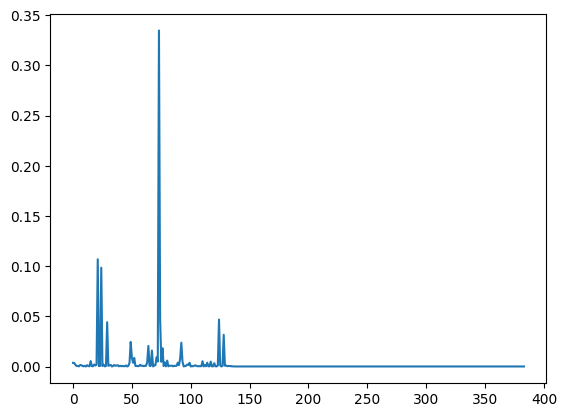

In [7]:
import matplotlib.pyplot as plt

plt.plot(start_probs[0])
plt.show

In [8]:
import collections

example_to_features = collections.defaultdict(list)
for idx, feature in enumerate(eval_set):
    example_to_features[feature["example_id"]].append(idx)

example_to_features

defaultdict(list,
            {'572746addd62a815002e9a61': [0],
             '5a592b593e1742001a15cfce': [1],
             '572a02483f37b3190047864e': [2],
             '5ad4fbeb5b96ef001a10a883': [3],
             '5ad03e5077cf76001a686ed4': [4],
             '5a2c14b4bfd06b001a5ae9d4': [5],
             '5a669d5cf038b7001ab0c05e': [6],
             '5a58feb63e1742001a15cf32': [7],
             '5728d7c54b864d1900164f4d': [8],
             '5a550e6f134fea001a0e187e': [9, 10, 11]})

In [9]:
import numpy as np

n_best = 10
max_answer_length = 30
predicted_answers = []
references = []

# for each question 
for example in small_eval_set:
    example_id = example["id"]
    context = example["context"]
    answers = []
    # and each feature, if the context was truncated
    for feature_index in example_to_features[example_id]:
        start_prob = start_probs[feature_index]
        end_prob = end_probs[feature_index]
        offsets = eval_set["offset_mapping"][feature_index]

        start_indexes = np.argsort(start_prob)[-1 : -n_best - 1 : -1].tolist()
        end_indexes = np.argsort(end_prob)[-1 : -n_best - 1 : -1].tolist() 

        no_answer_prob = start_prob[0] * end_prob[0]

        for start_index in start_indexes:
            for end_index in end_indexes:
                # Skip answers that are not fully in the context
                if offsets[start_index] is None or offsets[end_index] is None:
                    continue
                # Skip answers with a length that is either < 0 or > max_answer_length.
                if (
                    end_index < start_index
                    or end_index - start_index + 1 > max_answer_length
                ):
                    continue
                
                answers.append(
                    {
                        "text": context[offsets[start_index][0] : offsets[end_index][0]],
                        "score": start_prob[start_index] * end_prob[end_index],
                        "no_answer_probability": no_answer_prob,
                    }
                )

    if len(answers) > 0:
        best_answer = max(answers, key=lambda x: x["score"])
        predicted_answers.append({"id": example_id, "prediction_text": best_answer["text"], "no_answer_probability":best_answer["no_answer_probability"]})
    else:
        predicted_answers.append({"id": example_id, "prediction_text": "", "no_answer_probability":1.0})

    references.append({"id": example_id, "answers": example["answers"]})
    

In [10]:
predicted_answers

[{'id': '572746addd62a815002e9a61',
  'prediction_text': 'mandatory ',
  'no_answer_probability': np.float32(6.3390085e-06)},
 {'id': '5a592b593e1742001a15cfce',
  'prediction_text': 'signs of magnetic reversal',
  'no_answer_probability': np.float32(2.9009515e-08)},
 {'id': '572a02483f37b3190047864e',
  'prediction_text': 'Niels Je',
  'no_answer_probability': np.float32(7.771773e-08)},
 {'id': '5ad4fbeb5b96ef001a10a883',
  'prediction_text': 'rebuild Poland (especially Warsaw) was a major ',
  'no_answer_probability': np.float32(0.00013224977)},
 {'id': '5ad03e5077cf76001a686ed4',
  'prediction_text': '',
  'no_answer_probability': np.float32(5.5140083e-07)},
 {'id': '5a2c14b4bfd06b001a5ae9d4',
  'prediction_text': "'Pick ",
  'no_answer_probability': np.float32(6.0813613e-07)},
 {'id': '5a669d5cf038b7001ab0c05e',
  'prediction_text': 'MCI ',
  'no_answer_probability': np.float32(2.2030132e-05)},
 {'id': '5a58feb63e1742001a15cf32',
  'prediction_text': "William Smith almost a hundred

In [11]:
import evaluate

metric = evaluate.load("squad_v2")
results = metric.compute(predictions=predicted_answers, references=references)

In [12]:
results

{'exact': 10.0,
 'f1': 15.0,
 'total': 10,
 'HasAns_exact': 0.0,
 'HasAns_f1': 16.666666666666668,
 'HasAns_total': 3,
 'NoAns_exact': 14.285714285714286,
 'NoAns_f1': 14.285714285714286,
 'NoAns_total': 7,
 'best_exact': 70.0,
 'best_exact_thresh': 0.0,
 'best_f1': 70.0,
 'best_f1_thresh': 0.0}

In [15]:
f_results,_, _ = post_process(start_probs, end_probs, eval_set, small_eval_set)
f_results

{'exact': 10.0,
 'f1': 15.0,
 'total': 10,
 'HasAns_exact': 0.0,
 'HasAns_f1': 16.666666666666668,
 'HasAns_total': 3,
 'NoAns_exact': 14.285714285714286,
 'NoAns_f1': 14.285714285714286,
 'NoAns_total': 7,
 'best_exact': 70.0,
 'best_exact_thresh': 0.0,
 'best_f1': 70.0,
 'best_f1_thresh': 0.0}

In [ ]:
tokenized_train = reduced_set["train"].map(
    preprocess_train_function,
    batched=True,
    remove_columns=reduced_set["train"].column_names,
)

tokenized_eval = reduced_set["val"].map(
    preprocess_val_function,
    batched=True,
    remove_columns=reduced_set["val"].column_names,
)

Map:   0%|          | 0/6500 [00:00<?, ? examples/s]

Map:   0%|          | 0/650 [00:00<?, ? examples/s]

In [17]:
from transformers import AutoTokenizer

model_name = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [18]:
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator()

In [6]:
from transformers import TrainingArguments, Trainer

output_name = "tutorial_bert"
output_dir = os.path.join(os.getcwd(), "models", output_name)

In [ ]:
model = AutoModelForQuestionAnswering.from_pretrained(model_name).to(device)

training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,2.173286
2,3.098500,1.942451
3,2.020900,1.920318


TrainOutput(global_step=1233, training_loss=2.402234203527347, metrics={'train_runtime': 519.5924, 'train_samples_per_second': 37.934, 'train_steps_per_second': 2.373, 'total_flos': 1931379451223040.0, 'train_loss': 2.402234203527347, 'epoch': 3.0})

In [4]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, TrainingArguments

output_name = "tutorial_bert"
model_path = os.path.join(os.getcwd(), "models", output_name,"checkpoint-1233")
model = AutoModelForQuestionAnswering.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [5]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    processing_class=tokenizer
)

In [6]:
tokenized_test = reduced_set["test"].map(
    preprocess_val_function,
    batched=True,
    remove_columns=reduced_set["test"].column_names,
)

In [7]:
from torch.nn.functional import softmax
import torch

t_predictions, _, _ = trainer.predict(tokenized_test)
t_start_logits, t_end_logits = t_predictions
t_start_probs = softmax(torch.Tensor(t_start_logits), dim=-1).numpy()
t_end_probs = softmax(torch.Tensor(t_end_logits), dim=-1).numpy()

In [8]:
from processing import post_process

f_results,_, _ = post_process(t_start_probs, t_end_probs, tokenized_test, reduced_set["test"])
f_results

  0%|          | 0/650 [00:00<?, ?it/s]

{'exact': 23.692307692307693,
 'f1': 26.204657464469324,
 'total': 650,
 'HasAns_exact': 31.137724550898202,
 'HasAns_f1': 36.02702799971575,
 'HasAns_total': 334,
 'NoAns_exact': 15.822784810126583,
 'NoAns_f1': 15.822784810126583,
 'NoAns_total': 316,
 'best_exact': 49.23076923076923,
 'best_exact_thresh': 6.687567406515882e-07,
 'best_f1': 49.456410256410265,
 'best_f1_thresh': 1.244938857780653e-06}